<a href="https://colab.research.google.com/github/UleleBulele/ML-Analysis-of-Video-Games/blob/main/Report__Project_Group__B06C_D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Re-import necessary libraries and reload the dataset
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv('/content/drive/MyDrive/VideoGames.csv')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df_raw.head()

,Name,Platform,Year_of_Release,Genre,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,User_Score
0,SSX Tricky,GC,2001,Sports,0.42,0.11,0.00,0.01,0.54,87.0,8.6
1,Chaos Legion,PS2,2003,Action,0.15,0.12,0.00,0.04,0.30,65.0,8.2
2,RIGS: Mechanized Combat League,PS4,2016,Action,0.03,0.05,0.01,0.02,0.11,79.0,7.9
3,Sorcery,PS3,2012,Action,0.14,0.11,0.00,0.05,0.29,70.0,7.3
4,Tokobot,PSP,2005,Platform,0.06,0.00,0.00,0.00,0.06,72.0,7.3


In [ ]:
print(df_raw.isnull().sum())
print('\n', df_raw.shape)

Name                0
Platform            0
Year_of_Release     0
Genre               0
NA_Sales           21
EU_Sales           14
JP_Sales           17
Other_Sales        14
Global_Sales       18
Critic_Score       19
User_Score         15
dtype: int64

 (6250, 11)


In [ ]:
df = df_raw.dropna()
print(df.isnull().sum())
print('\n', df.shape)


Name               0
Platform           0
Year_of_Release    0
Genre              0
NA_Sales           0
EU_Sales           0
JP_Sales           0
Other_Sales        0
Global_Sales       0
Critic_Score       0
User_Score         0
dtype: int64

 (6142, 11)


,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,User_Score
count,6142.000000,6142.000000,6142.00000,6142.000000,6142.000000,6142.000000,6142.000000
mean,0.401923,0.242099,0.06732,0.085083,0.796599,69.939759,7.143683
std,1.004664,0.717320,0.30042,0.282798,2.048635,13.968313,1.458107
min,0.000000,0.000000,0.00000,0.000000,0.010000,13.000000,0.500000
25%,0.060000,0.020000,0.00000,0.010000,0.110000,61.000000,6.400000
50%,0.150000,0.060000,0.00000,0.020000,0.290000,72.000000,7.500000
75%,0.390000,0.207500,0.01000,0.070000,0.750000,80.000000,8.200000
max,41.360000,28.960000,6.50000,10.570000,82.530000,98.000000,9.600000


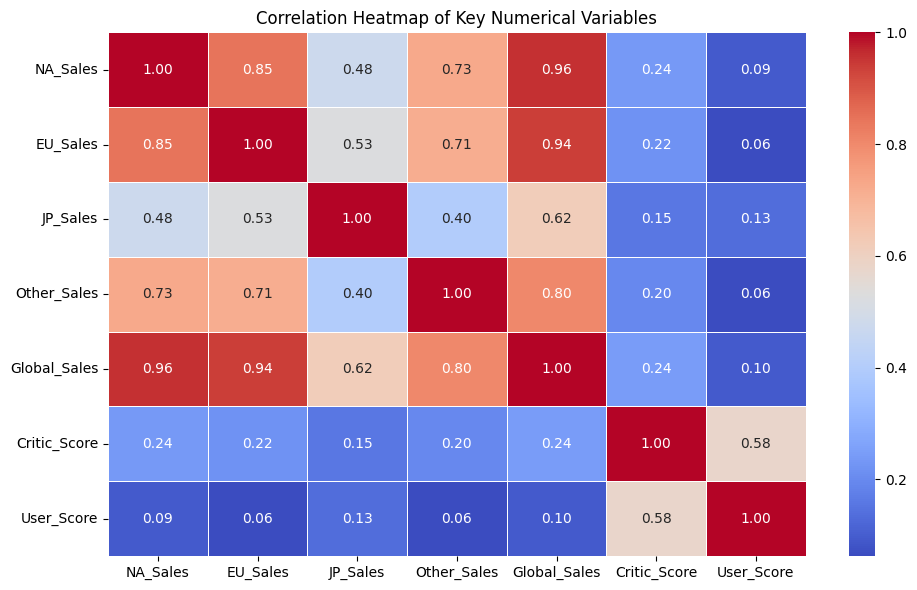

In [ ]:
numeric_columns = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales',
                   'Global_Sales', 'Critic_Score', 'User_Score']

desc_stats = df[numeric_columns].describe()

plt.figure(figsize=(10, 6))
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Key Numerical Variables')
plt.tight_layout()

desc_stats


Text(0, 0.5, 'Global Sales (millions)')

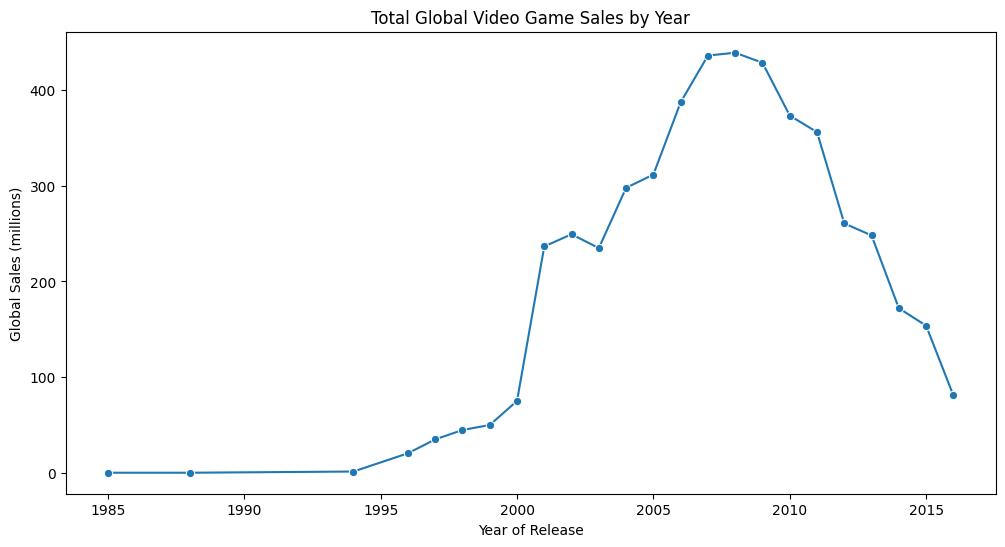

In [ ]:
sales_by_year = df.groupby('Year_of_Release')['Global_Sales'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year_of_Release', y='Global_Sales', data=sales_by_year, marker='o')
plt.title('Total Global Video Game Sales by Year')
plt.xlabel('Year of Release')
plt.ylabel('Global Sales (millions)')

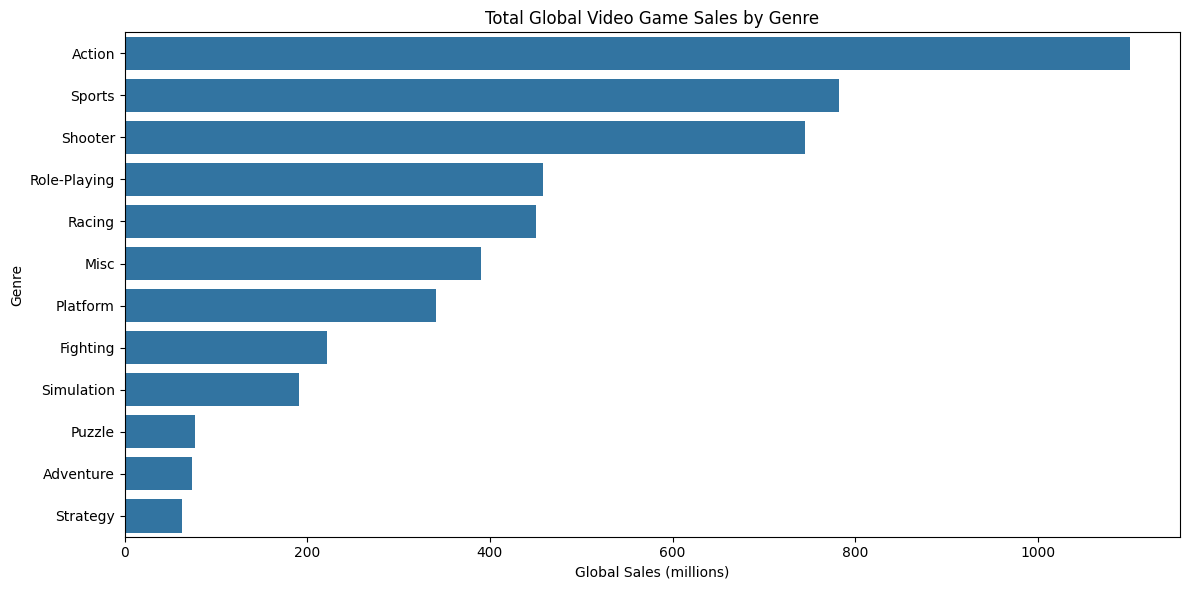

In [ ]:
sales_by_genre = df.groupby('Genre')['Global_Sales'].sum().reset_index().sort_values(by='Global_Sales', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x='Global_Sales', y='Genre', data=sales_by_genre)
plt.title('Total Global Video Game Sales by Genre')
plt.ylabel('Genre')
plt.xlabel('Global Sales (millions)')
plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6142 entries, 0 to 6249
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             6142 non-null   object 
 1   Platform         6142 non-null   object 
 2   Year_of_Release  6142 non-null   int64  
 3   Genre            6142 non-null   object 
 4   NA_Sales         6142 non-null   float64
 5   EU_Sales         6142 non-null   float64
 6   JP_Sales         6142 non-null   float64
 7   Other_Sales      6142 non-null   float64
 8   Global_Sales     6142 non-null   float64
 9   Critic_Score     6142 non-null   float64
 10  User_Score       6142 non-null   float64
dtypes: float64(7), int64(1), object(3)
memory usage: 575.8+ KB


Text(0.5, 1.02, 'Pairplot of Numerical Variables')

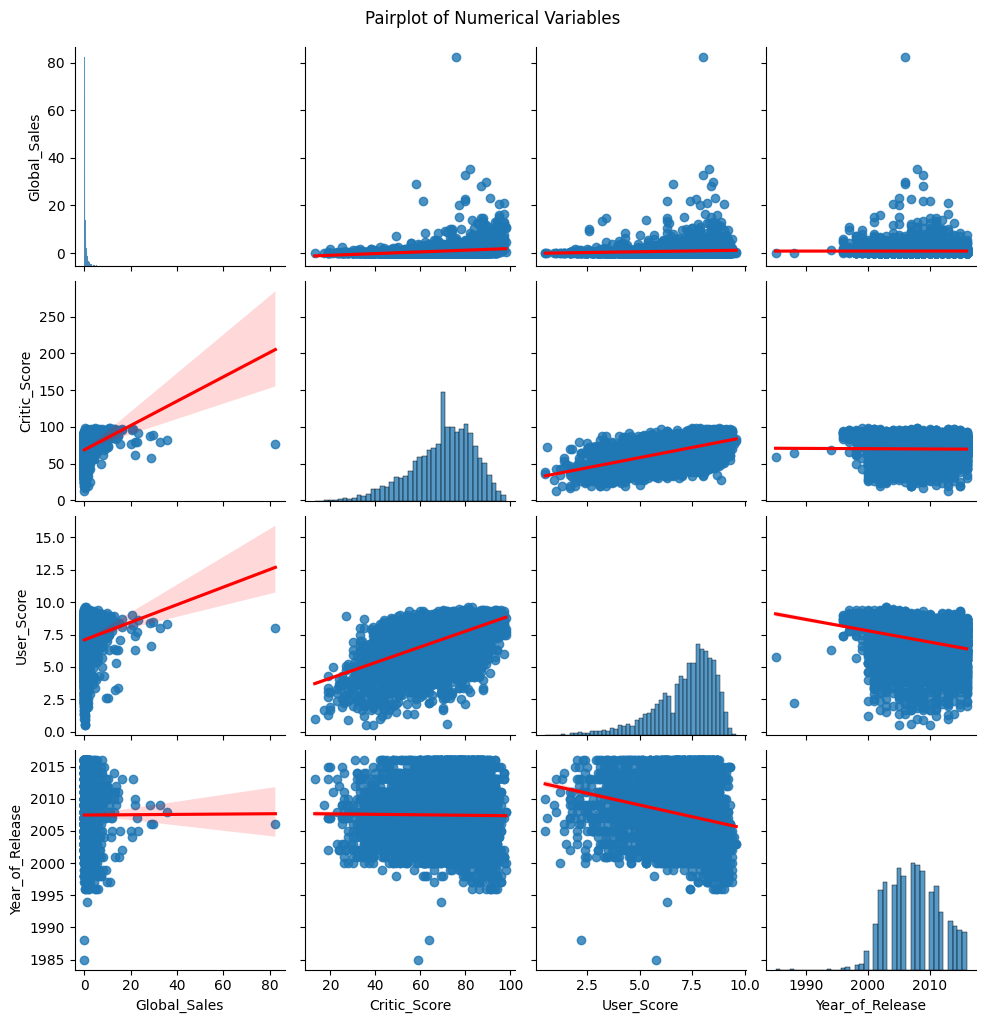

In [ ]:
sns.pairplot(data=df, vars=['Global_Sales', 'Critic_Score', 'User_Score', 'Year_of_Release'], kind='reg', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('Pairplot of Numerical Variables', y=1.02)

Text(0.5, 1.02, 'Pairplot of Numerical Variables')

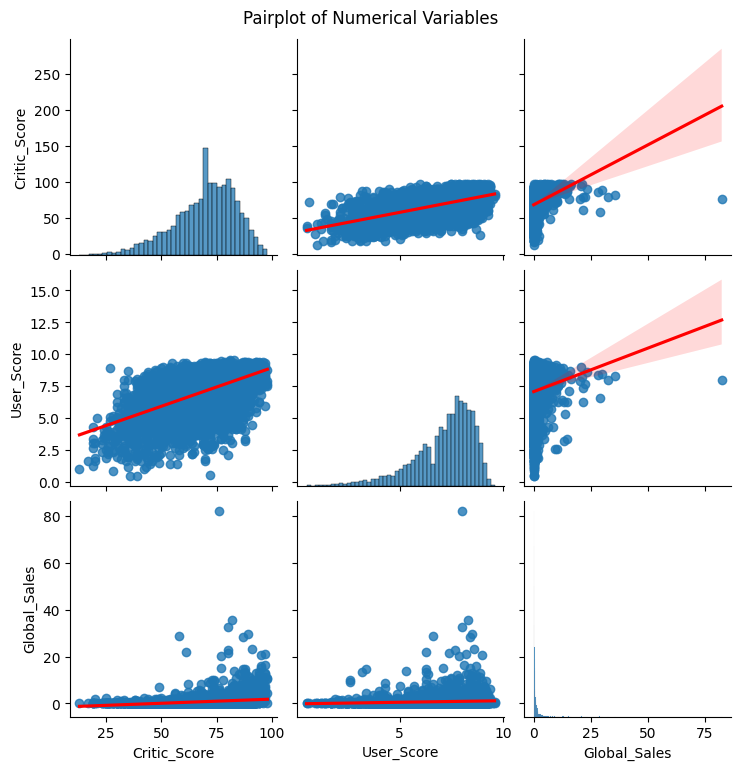

In [ ]:
sns.pairplot(data=df, vars=["Critic_Score", "User_Score", "Global_Sales"], kind='reg', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('Pairplot of Numerical Variables', y=1.02)

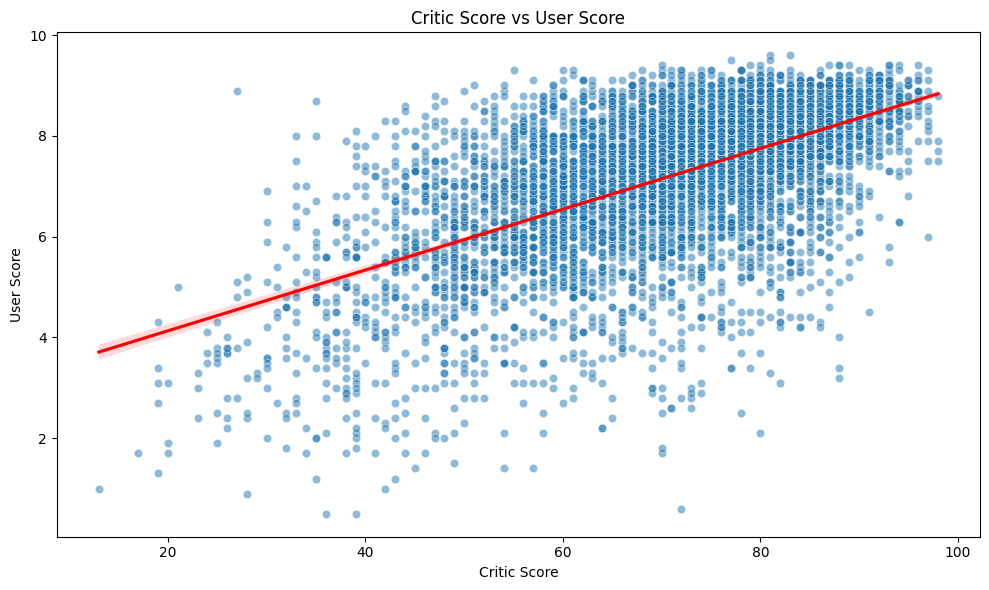

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Critic_Score", y="User_Score", alpha=0.5)
sns.regplot(data=df, x="Critic_Score", y="User_Score", scatter=False, color="red")
plt.title("Critic Score vs User Score")
plt.xlabel("Critic Score")
plt.ylabel("User Score")
plt.tight_layout()
plt.show()


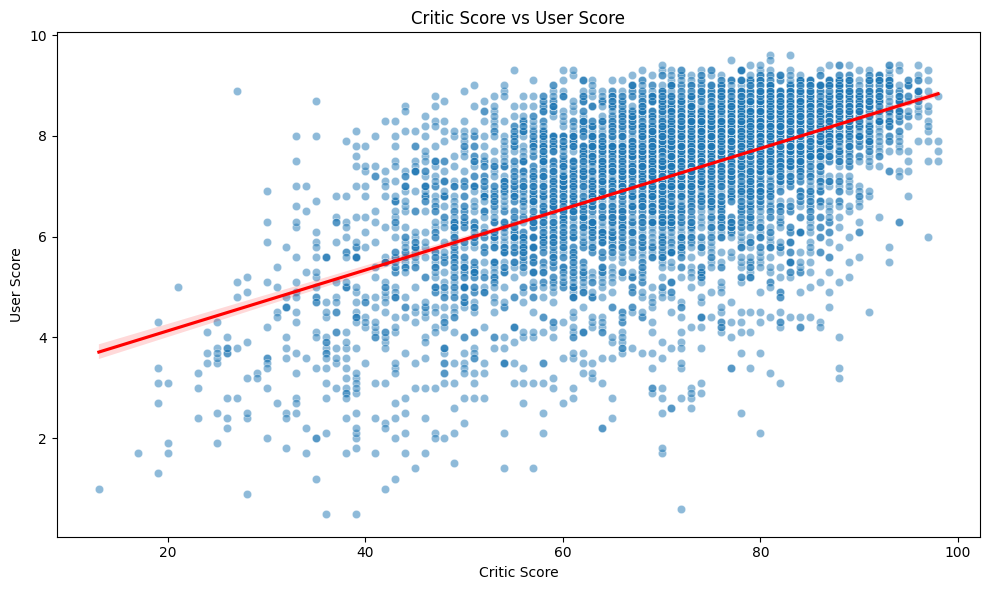

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Critic_Score", y="User_Score", alpha=0.5)
sns.regplot(data=df, x="Critic_Score", y="User_Score", scatter=False, color="red")
plt.title("Critic Score vs User Score")
plt.xlabel("Critic Score")
plt.ylabel("User Score")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

features = ['Critic_Score', 'User_Score']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()


,Critic_Score,User_Score
0,1.221452,0.998854
1,-0.353669,0.724503
2,0.648681,0.518740
3,0.004313,0.107214
4,0.147506,0.107214


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
df_model = df_raw[['Critic_Score', 'User_Score', 'Global_Sales']].dropna()

X = df_model[['Critic_Score', 'User_Score']]
y = df_model['Global_Sales']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", round(r2, 3))
print("RMSE:", round(rmse, 3))

R²: 0.117
RMSE: 1.528


In [ ]:
# Re-import necessary libraries after code execution state reset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Convert relevant columns to numeric
df["User_Score"] = pd.to_numeric(df["User_Score"], errors="coerce")
df["Year_of_Release"] = pd.to_numeric(df["Year_of_Release"], errors="coerce")

# Dataset 1: Predicting Global Sales based on Critic and User Scores
df_model_1 = df[['Global_Sales', 'Critic_Score', 'User_Score']].dropna()
X1 = df_model_1[['Critic_Score', 'User_Score']]
y1 = df_model_1['Global_Sales']
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1_scaled, y1, test_size=0.2, random_state=42)
model1 = LinearRegression()
model1.fit(X1_train, y1_train)
y1_pred = model1.predict(X1_test)
mse1 = mean_squared_error(y1_test, y1_pred)
r2_1 = r2_score(y1_test, y1_pred)

# Dataset 2: Predicting Critic Score based on Regional Sales
df_model_2 = df[['Critic_Score', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].dropna()
X2 = df_model_2[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]
y2 = df_model_2['Critic_Score']
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2_scaled, y2, test_size=0.2, random_state=42)
model2 = LinearRegression()
model2.fit(X2_train, y2_train)
y2_pred = model2.predict(X2_test)
mse2 = mean_squared_error(y2_test, y2_pred)
r2_2 = r2_score(y2_test, y2_pred)

# Dataset 3: Predicting User Score based on Critic Score and Year of Release
df_model_3 = df[['User_Score', 'Critic_Score', 'Year_of_Release']].dropna()
X3 = df_model_3[['Critic_Score', 'Year_of_Release']]
y3 = df_model_3['User_Score']
scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3_scaled, y3, test_size=0.2, random_state=42)
model3 = LinearRegression()
model3.fit(X3_train, y3_train)
y3_pred = model3.predict(X3_test)
mse3 = mean_squared_error(y3_test, y3_pred)
r2_3 = r2_score(y3_test, y3_pred)

# Return model evaluation metrics
{
    "Model 1: Predict Global Sales": {"MSE": mse1, "R^2": r2_1},
    "Model 2: Predict Critic Score": {"MSE": mse2, "R^2": r2_2},
    "Model 3: Predict User Score": {"MSE": mse3, "R^2": r2_3}
}


{'Model 1: Predict Global Sales': {'MSE': 2.1781770642916918,
  'R^2': 0.10030085441668835},
 'Model 2: Predict Critic Score': {'MSE': 181.59608505724327,
  'R^2': 0.06633921612686633},
 'Model 3: Predict User Score': {'MSE': 1.2952132042169087,
  'R^2': 0.3667014928201071}}

<ipython-input-26-5f4239fd4266>:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x="Cluster", y="Global_Sales", palette="Set2")


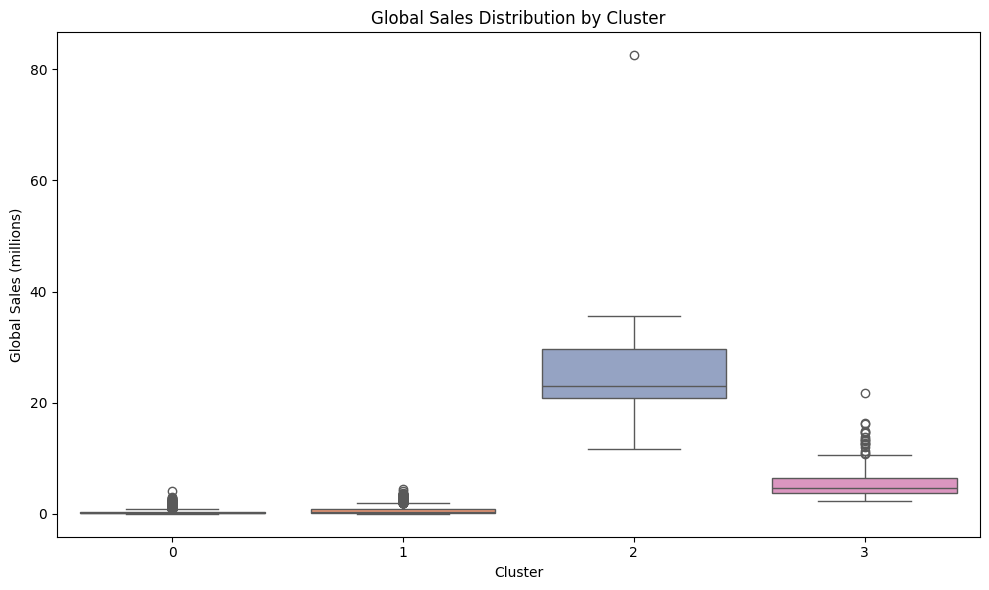

In [ ]:
# Re-import libraries due to code execution environment reset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans

# Drop rows with missing Global_Sales
df = df.dropna(subset=["Global_Sales"])

# Keep only top platforms and genres to reduce dimensionality
top_platforms = df['Platform'].value_counts().nlargest(10).index
top_genres = df['Genre'].value_counts().nlargest(10).index
df_filtered = df[df['Platform'].isin(top_platforms) & df['Genre'].isin(top_genres)]

# Define features and target
features_filtered = df_filtered.drop(columns=["Name", "Global_Sales"])
categorical_cols = ["Platform", "Genre"]
numerical_cols = ["Year_of_Release", "Critic_Score", "User_Score"]

# Preprocessing pipelines
numerical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numerical_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Fit and transform features
X_filtered_preprocessed = preprocessor.fit_transform(features_filtered)

# Apply KMeans clustering
kmeans_final = KMeans(n_clusters=4, random_state=0, n_init=10)
clusters = kmeans_final.fit_predict(X_filtered_preprocessed)

# Add cluster labels to the DataFrame
df_filtered = df_filtered.copy()
df_filtered["Cluster"] = clusters

# Plot the relationship between clusters and Global_Sales
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_filtered, x="Cluster", y="Global_Sales", palette="Set2")
plt.title("Global Sales Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Global Sales (millions)")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report

# Drop rows with missing Global_Sales
df = df.dropna(subset=["Global_Sales"])

# Binarize Global_Sales: 1 if above median, 0 if below
threshold = df["Global_Sales"].median()
df["High_Sales"] = (df["Global_Sales"] > threshold).astype(int)

# Define features and target
features = df.drop(columns=["Name", "Global_Sales", "High_Sales"])
target = df["High_Sales"]

categorical_cols = ["Platform", "Genre"]
numerical_cols = ["Critic_Score", "User_Score"]

# Preprocessing
numerical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numerical_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# Create pipeline with Logistic Regression
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression())
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Fit the model
pipeline.fit(X_train, y_train)

# Predict and evaluate
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
df

              precision    recall  f1-score   support

           0       0.72      0.67      0.69       655
           1       0.65      0.70      0.68       574

    accuracy                           0.68      1229
   macro avg       0.68      0.68      0.68      1229
weighted avg       0.69      0.68      0.68      1229



,Name,Platform,Year_of_Release,Genre,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,User_Score,Cluster,High_Sales
0,SSX Tricky,GC,2001,Sports,0.42,0.11,0.00,0.01,0.54,87.0,8.6,0,1
1,Chaos Legion,PS2,2003,Action,0.15,0.12,0.00,0.04,0.30,65.0,8.2,0,1
2,RIGS: Mechanized Combat League,PS4,2016,Action,0.03,0.05,0.01,0.02,0.11,79.0,7.9,1,0
3,Sorcery,PS3,2012,Action,0.14,0.11,0.00,0.05,0.29,70.0,7.3,1,0
4,Tokobot,PSP,2005,Platform,0.06,0.00,0.00,0.00,0.06,72.0,7.3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6245,Super Ghouls 'n Ghosts,GBA,2002,Platform,0.05,0.02,0.00,0.00,0.07,78.0,8.8,0,0
6246,SWAT: Global Strike Team,PS2,2003,Shooter,0.16,0.12,0.00,0.04,0.32,69.0,7.8,0,1
6247,The Lord of the Rings: The Two Towers,GC,2002,Action,0.41,0.11,0.00,0.01,0.53,82.0,8.7,0,1
6248,Dance Dance Revolution Ultramix 3,XB,2005,Simulation,0.28,0.08,0.00,0.01,0.38,75.0,8.6,0,1
